In [ ]:
# ============================================================
# Diabetes Prediction
# Optimasi Pemilihan Fitur dengan Algoritma Genetika & Random Forest
# Adaptasi dari: Gori & Hestiningtyas (2024), IJCS Vol. 13, Issue 5
# ============================================================
# Dataset : diabetes_prediction_dataset.csv
# Sumber   : https://www.kaggle.com/datasets/iammustafatz/diabetes-prediction-dataset
# ALUR     : RF Baseline → GA-FS (Feature Selection) → RF+GA-FS → GS → RF+GA-FS+GS
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay
)
import random
import warnings
warnings.filterwarnings('ignore')
print('Library berhasil dimuat.')

Library berhasil dimuat.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

## 1. Load Dataset

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')
# df = pd.read_csv('/content/drive/MyDrive/diabetes_prediction_dataset.csv')

# Jika file berada di direktori yang sama:
df = pd.read_csv('diabetes_prediction_dataset.csv')
print('=' * 60)
print('INFORMASI DATASET')
print('=' * 60)
print(f'Jumlah data  : {df.shape[0]} baris, {df.shape[1]} kolom')
print(f'Kolom        : {list(df.columns)}')
print(f'Tipe data:\n{df.dtypes}')
print(f'Statistik deskriptif:\n{df.describe()}')
print(f'5 data pertama:\n{df.head()}')

INFORMASI DATASET
Jumlah data  : 100000 baris, 9 kolom
Kolom        : ['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history', 'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes']
Tipe data:
gender                  object
age                    float64
hypertension             int64
heart_disease            int64
smoking_history         object
bmi                    float64
HbA1c_level            float64
blood_glucose_level      int64
diabetes                 int64
dtype: object
Statistik deskriptif:
                 age  hypertension  heart_disease            bmi  \
count  100000.000000  100000.00000  100000.000000  100000.000000   
mean       41.885856       0.07485       0.039420      27.320767   
std        22.516840       0.26315       0.194593       6.636783   
min         0.080000       0.00000       0.000000      10.010000   
25%        24.000000       0.00000       0.000000      23.630000   
50%        43.000000       0.00000       0.000000      27.320000   
7

## 2. Data Preprocessing

In [ ]:
# --- 2a. Data Cleaning ---
print('=' * 60)
print('DATA CLEANING')
print('=' * 60)

print(f'Missing values:\n{df.isnull().sum()}')
print(f'Jumlah data duplikat: {df.duplicated().sum()}')
df = df.drop_duplicates()
print(f'Jumlah data setelah hapus duplikat: {len(df)}')

DATA CLEANING
Missing values:
gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64
Jumlah data duplikat: 3854
Jumlah data setelah hapus duplikat: 96146


DISTRIBUSI DATA TARGET (diabetes)
diabetes
0    87664
1     8482
Name: count, dtype: int64


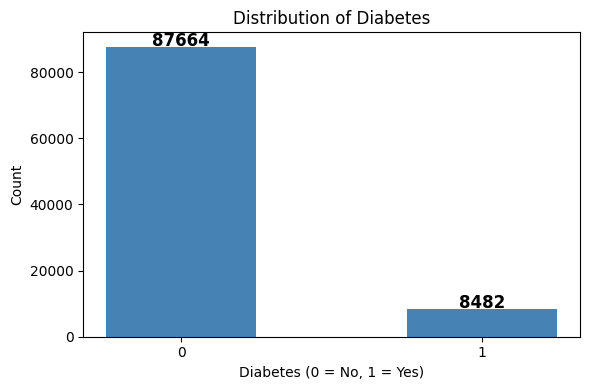

Gambar disimpan: distribusi_data.png


In [ ]:
# --- 2b. Distribusi Target ---
print('=' * 60)
print('DISTRIBUSI DATA TARGET (diabetes)')
print('=' * 60)
print(df['diabetes'].value_counts())

plt.figure(figsize=(6, 4))
counts = df['diabetes'].value_counts().sort_index()
bars = plt.bar(counts.index, counts.values, color='steelblue', width=0.5)
for bar, val in zip(bars, counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, val + 200, str(val),
             ha='center', fontsize=12, fontweight='bold')
plt.title('Distribution of Diabetes')
plt.xlabel('Diabetes (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.xticks([0, 1])
plt.tight_layout()
plt.savefig('distribusi_data.png', dpi=150)
plt.show()
print('Gambar disimpan: distribusi_data.png')

In [ ]:
# --- 2c. Label Encoding ---
print('=' * 60)
print('DATA TRANSFORMATION - Label Encoding')
print('=' * 60)
print('Sebelum Label Encoding:')
print(df.head())

# Kolom kategorikal:
# gender         : Female=0, Male=1, Other=2
# smoking_history: current=0, ever=1, former=2, never=3, No Info=4, not current=5
categorical_cols = ['gender', 'smoking_history']

le = LabelEncoder()
df_encoded = df.copy()
label_encoders = {}

for col in categorical_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col])
    label_encoders[col] = le
    print(f'  {col}: {dict(zip(le.classes_, le.transform(le.classes_)))}')

print('\nSetelah Label Encoding:')
print(df_encoded.head())

DATA TRANSFORMATION - Label Encoding
Sebelum Label Encoding:
   gender   age  hypertension  heart_disease smoking_history    bmi  \
0  Female  80.0             0              1           never  25.19   
1  Female  54.0             0              0         No Info  27.32   
2    Male  28.0             0              0           never  27.32   
3  Female  36.0             0              0         current  23.45   
4    Male  76.0             1              1         current  20.14   

   HbA1c_level  blood_glucose_level  diabetes  
0          6.6                  140         0  
1          6.6                   80         0  
2          5.7                  158         0  
3          5.0                  155         0  
4          4.8                  155         0  
  gender: {'Female': np.int64(0), 'Male': np.int64(1), 'Other': np.int64(2)}
  smoking_history: {'No Info': np.int64(0), 'current': np.int64(1), 'ever': np.int64(2), 'former': np.int64(3), 'never': np.int64(4), 'not current'

## 3. Data Splitting (80:20)

DATA SPLITTING (80% Training : 20% Testing)
Fitur awal (8 fitur): ['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history', 'bmi', 'HbA1c_level', 'blood_glucose_level']
Total data training : 76916
  Kelas 0 (No) : 70130
  Kelas 1 (Yes): 6786
Total data testing  : 19230
  Kelas 0 (No) : 17534
  Kelas 1 (Yes): 1696


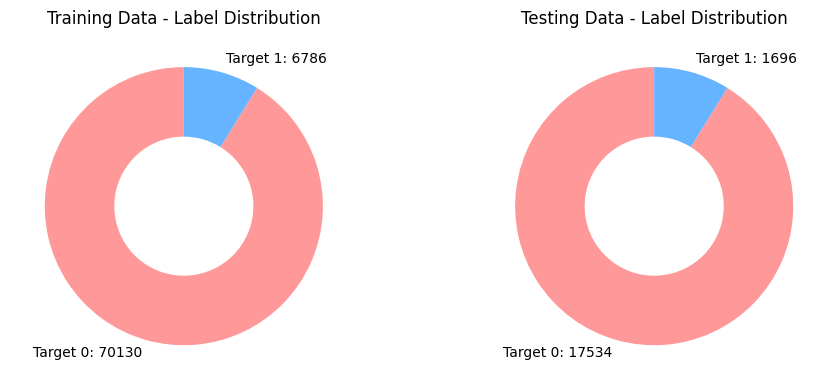

Gambar disimpan: distribusi_train_test.png


In [ ]:
print('=' * 60)
print('DATA SPLITTING (80% Training : 20% Testing)')
print('=' * 60)

X_all = df_encoded.drop('diabetes', axis=1)
y     = df_encoded['diabetes']

print(f'Fitur awal ({len(X_all.columns)} fitur): {list(X_all.columns)}')

X_train_all, X_test_all, y_train, y_test = train_test_split(
    X_all, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Total data training : {len(X_train_all)}')
print(f'  Kelas 0 (No) : {sum(y_train == 0)}')
print(f'  Kelas 1 (Yes): {sum(y_train == 1)}')
print(f'Total data testing  : {len(X_test_all)}')
print(f'  Kelas 0 (No) : {sum(y_test == 0)}')
print(f'  Kelas 1 (Yes): {sum(y_test == 1)}')

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
train_counts = y_train.value_counts().sort_index()
test_counts  = y_test.value_counts().sort_index()

axes[0].pie(train_counts,
            labels=[f'Target 0: {train_counts[0]}', f'Target 1: {train_counts[1]}'],
            colors=['#ff9999','#66b3ff'], startangle=90, wedgeprops=dict(width=0.5))
axes[0].set_title('Training Data - Label Distribution')

axes[1].pie(test_counts,
            labels=[f'Target 0: {test_counts[0]}', f'Target 1: {test_counts[1]}'],
            colors=['#ff9999','#66b3ff'], startangle=90, wedgeprops=dict(width=0.5))
axes[1].set_title('Testing Data - Label Distribution')

plt.tight_layout()
plt.savefig('distribusi_train_test.png', dpi=150)
plt.show()
print('Gambar disimpan: distribusi_train_test.png')

## 4. Model 1: Random Forest Baseline (Tanpa Optimasi)

MODEL 1: RANDOM FOREST BASELINE (Semua Fitur, Tanpa Optimasi)
Accuracy : 96.97%
Precision: 95.06%
Recall   : 69.22%
F1-Score : 80.11%


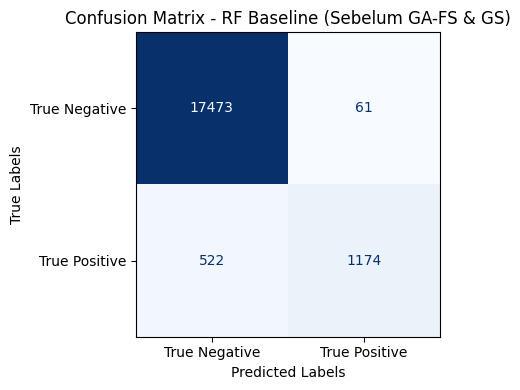

Gambar disimpan: cm_rf_baseline.png


In [ ]:
print('=' * 60)
print('MODEL 1: RANDOM FOREST BASELINE (Semua Fitur, Tanpa Optimasi)')
print('=' * 60)

rf_base = RandomForestClassifier(random_state=42)
rf_base.fit(X_train_all, y_train)
y_pred_rf = rf_base.predict(X_test_all)

acc_rf  = accuracy_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf)
rec_rf  = recall_score(y_test, y_pred_rf)
f1_rf   = f1_score(y_test, y_pred_rf)

print(f'Accuracy : {acc_rf * 100:.2f}%')
print(f'Precision: {prec_rf * 100:.2f}%')
print(f'Recall   : {rec_rf * 100:.2f}%')
print(f'F1-Score : {f1_rf * 100:.2f}%')

cm_rf = confusion_matrix(y_test, y_pred_rf)
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(confusion_matrix=cm_rf,
    display_labels=['True Negative', 'True Positive']).plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix - RF Baseline (Sebelum GA-FS & GS)')
ax.set_xlabel('Predicted Labels')
ax.set_ylabel('True Labels')
plt.tight_layout()
plt.savefig('cm_rf_baseline.png', dpi=150)
plt.show()
print('Gambar disimpan: cm_rf_baseline.png')

## 5. Feature Selection: Genetic Algorithm (GA-FS)

> **Catatan:** GA-FS dilakukan **LEBIH DULU** sebelum GridSearchCV.
> GA menggunakan RF default sebagai fitness function untuk mencari subset fitur terbaik.
> Setelah fitur optimal ditemukan, barulah parameter dioptimalkan dengan GridSearchCV.

In [ ]:
print('=' * 60)
print('FEATURE SELECTION: GENETIC ALGORITHM (GA-FS)')
print('=' * 60)

# ── Parameter GA - sesuai Tabel 3 jurnal ──────────────────────
GENERATIONS = 30
POPULATION  = 50
CROSSOVER   = 0.5
MUTATION    = 0.07
N_FEATURES  = X_train_all.shape[1]

print(f'Fitur awal ({N_FEATURES}): {list(X_train_all.columns)}')
print(f'Parameter GA: Generasi={GENERATIONS}, Populasi={POPULATION}, '
      f'Crossover={CROSSOVER}, Mutasi={MUTATION}')

# ── Optimasi 1: Subsample data untuk fitness evaluation ───────
# Menggunakan 20% data training sebagai proxy → 16x lebih cepat
# Akurasi ranking antar kromosom tetap konsisten
SAMPLE_RATIO = 0.2
n_sample     = int(len(X_train_all) * SAMPLE_RATIO)
idx_sample   = np.random.choice(len(X_train_all), n_sample, replace=False)
X_tr_fast    = X_train_all.iloc[idx_sample].reset_index(drop=True)
y_tr_fast    = y_train.iloc[idx_sample].reset_index(drop=True)

print(f'\nOptimasi: fitness dievaluasi pada {n_sample} sampel ({SAMPLE_RATIO*100:.0f}% training data)')
print(f'Model final tetap dilatih pada SELURUH data training (verifikasi di akhir)\n')


def fitness_function(chromosome, X_tr, y_tr, X_te, y_te):
    """Fitness: akurasi RF dengan n_estimators kecil & max_depth terbatas
       (cukup untuk membedakan kualitas fitur, bukan model final)."""
    selected = [i for i, bit in enumerate(chromosome) if bit == 1]
    if len(selected) == 0:
        return 0.0
    # Optimasi 2: RF ringan untuk evaluasi cepat
    model = RandomForestClassifier(
        n_estimators=20,   # cukup 20 pohon (bukan 100)
        max_depth=10,      # batasi kedalaman
        random_state=42,
        n_jobs=-1
    )
    model.fit(X_tr.iloc[:, selected], y_tr)
    return accuracy_score(y_te, model.predict(X_te.iloc[:, selected]))


def initialize_population(pop_size, n_features):
    # Optimasi 3: inisialisasi dengan ~50% fitur aktif (bukan pure random)
    pop = []
    for _ in range(pop_size):
        chrom = [1 if np.random.random() < 0.5 else 0 for _ in range(n_features)]
        if sum(chrom) == 0:   # pastikan minimal 1 fitur
            chrom[np.random.randint(n_features)] = 1
        pop.append(chrom)
    return pop


def tournament_selection(population, fitnesses, k=3):
    selected = random.sample(list(zip(population, fitnesses)), k)
    selected.sort(key=lambda x: x[1], reverse=True)
    return list(selected[0][0])


def crossover_op(p1, p2, rate):
    if random.random() < rate:
        pt = random.randint(1, len(p1) - 1)
        return p1[:pt] + p2[pt:], p2[:pt] + p1[pt:]
    return p1[:], p2[:]


def mutate(chrom, rate):
    return [1 - bit if random.random() < rate else bit for bit in chrom]


# ── Jalankan GA ───────────────────────────────────────────────
print('Menjalankan Genetic Algorithm...')
random.seed(42)
np.random.seed(42)

population      = initialize_population(POPULATION, N_FEATURES)
best_chromosome = None
best_fitness    = 0.0
best_per_gen    = []
avg_per_gen     = []

for gen in range(GENERATIONS):
    # Evaluasi fitness pada subsample (cepat)
    fitnesses = [fitness_function(c, X_tr_fast, y_tr_fast, X_test_all, y_test)
                 for c in population]

    gen_best = max(fitnesses)
    gen_avg  = np.mean(fitnesses)
    best_per_gen.append(gen_best)
    avg_per_gen.append(gen_avg)

    if gen_best > best_fitness:
        best_fitness    = gen_best
        best_chromosome = population[fitnesses.index(gen_best)][:]

    print(f'  Gen {gen+1:2d}/{GENERATIONS} | Best: {gen_best:.4f} | '
          f'Avg: {gen_avg:.4f} | Fitur terpilih: {sum(best_chromosome)}')

    # Elitism: simpan 2 terbaik
    sorted_pop = [x for _, x in sorted(zip(fitnesses, population),
                                        key=lambda p: p[0], reverse=True)]
    new_pop = [sorted_pop[0][:], sorted_pop[1][:]]
    while len(new_pop) < POPULATION:
        c1, c2 = crossover_op(
            tournament_selection(population, fitnesses),
            tournament_selection(population, fitnesses),
            CROSSOVER
        )
        new_pop += [mutate(c1, MUTATION), mutate(c2, MUTATION)]
    population = new_pop[:POPULATION]

print(f'\nGA selesai! Best Fitness (subsample): {best_fitness * 100:.2f}%')
print(f'Kromosom terbaik: {best_chromosome}')

FEATURE SELECTION: GENETIC ALGORITHM (GA-FS)
Fitur awal (8): ['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history', 'bmi', 'HbA1c_level', 'blood_glucose_level']
Parameter GA: Generasi=30, Populasi=50, Crossover=0.5, Mutasi=0.07

Optimasi: fitness dievaluasi pada 15383 sampel (20% training data)
Model final tetap dilatih pada SELURUH data training (verifikasi di akhir)

Menjalankan Genetic Algorithm...
  Gen  1/30 | Best: 0.9718 | Avg: 0.9444 | Fitur terpilih: 4
  Gen  2/30 | Best: 0.9718 | Avg: 0.9560 | Fitur terpilih: 4
  Gen  3/30 | Best: 0.9719 | Avg: 0.9669 | Fitur terpilih: 7
  Gen  4/30 | Best: 0.9719 | Avg: 0.9681 | Fitur terpilih: 7
  Gen  5/30 | Best: 0.9722 | Avg: 0.9699 | Fitur terpilih: 6
  Gen  6/30 | Best: 0.9722 | Avg: 0.9701 | Fitur terpilih: 6
  Gen  7/30 | Best: 0.9722 | Avg: 0.9672 | Fitur terpilih: 6
  Gen  8/30 | Best: 0.9722 | Avg: 0.9689 | Fitur terpilih: 6
  Gen  9/30 | Best: 0.9722 | Avg: 0.9698 | Fitur terpilih: 6
  Gen 10/30 | Best: 0.9722 | Av

HASIL FEATURE SELECTION (GA-FS)
Fitur TERPILIH (6): ['gender', 'hypertension', 'smoking_history', 'bmi', 'HbA1c_level', 'blood_glucose_level']
Fitur DIELIMINASI (2): ['age', 'heart_disease']

Fitur yang dieliminasi GA adalah fitur yang tidak memberikan
kontribusi signifikan terhadap akurasi prediksi diabetes.


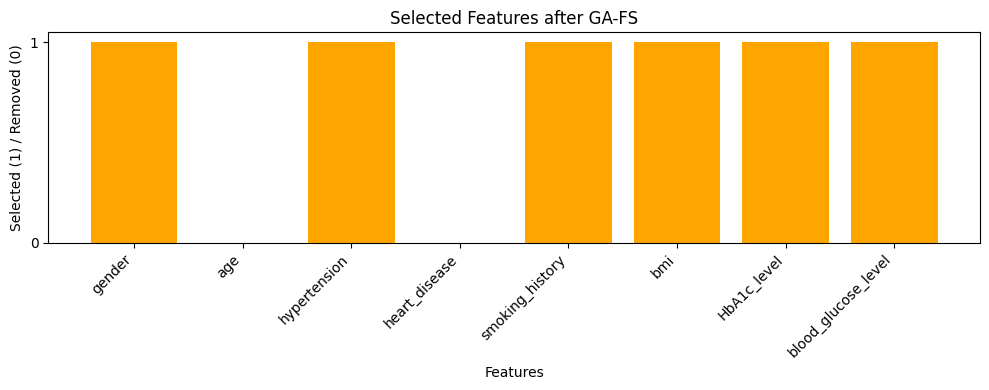

Gambar disimpan: selected_features_gafs.png


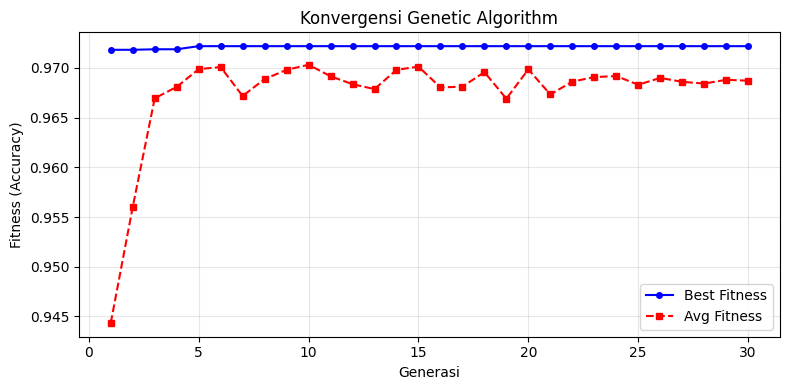

Gambar disimpan: ga_convergence.png


In [ ]:
print('=' * 60)
print('HASIL FEATURE SELECTION (GA-FS)')
print('=' * 60)

all_features      = list(X_train_all.columns)
selected_features = [all_features[i] for i, b in enumerate(best_chromosome) if b == 1]
removed_features  = [all_features[i] for i, b in enumerate(best_chromosome) if b == 0]

print(f'Fitur TERPILIH ({len(selected_features)}): {selected_features}')
print(f'Fitur DIELIMINASI ({len(removed_features)}): {removed_features}')
print()
print('Fitur yang dieliminasi GA adalah fitur yang tidak memberikan')
print('kontribusi signifikan terhadap akurasi prediksi diabetes.')

X_train_sel = X_train_all[selected_features]
X_test_sel  = X_test_all[selected_features]

# Plot fitur terpilih
colors = ['#FFA500' if b == 1 else '#CCCCCC' for b in best_chromosome]
plt.figure(figsize=(10, 4))
plt.bar(all_features, best_chromosome, color=colors)
plt.title('Selected Features after GA-FS')
plt.xlabel('Features')
plt.ylabel('Selected (1) / Removed (0)')
plt.xticks(rotation=45, ha='right')
plt.yticks([0, 1])
plt.tight_layout()
plt.savefig('selected_features_gafs.png', dpi=150)
plt.show()
print('Gambar disimpan: selected_features_gafs.png')

# Plot konvergensi GA
plt.figure(figsize=(8, 4))
plt.plot(range(1, GENERATIONS+1), best_per_gen, 'b-o', ms=4, label='Best Fitness')
plt.plot(range(1, GENERATIONS+1), avg_per_gen,  'r--s', ms=4, label='Avg Fitness')
plt.title('Konvergensi Genetic Algorithm')
plt.xlabel('Generasi')
plt.ylabel('Fitness (Accuracy)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('ga_convergence.png', dpi=150)
plt.show()
print('Gambar disimpan: ga_convergence.png')

## 6. Model 2: RF + GA-FS (Fitur Terpilih, Tanpa GS)

MODEL 2: RF + GA-FS (Fitur Terpilih, Parameter Default)
Accuracy : 96.59%
Precision: 89.22%
Recall   : 69.81%
F1-Score : 78.33%


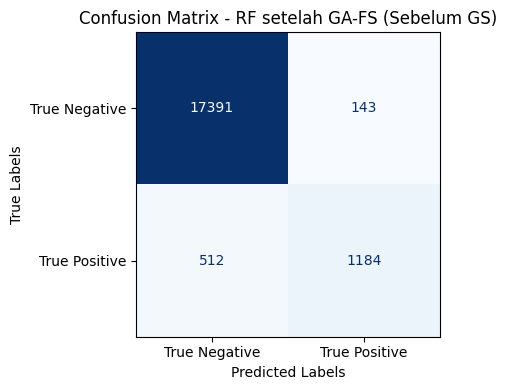

Gambar disimpan: cm_rf_gafs.png


In [ ]:
print('=' * 60)
print('MODEL 2: RF + GA-FS (Fitur Terpilih, Parameter Default)')
print('=' * 60)

rf_gafs = RandomForestClassifier(random_state=42)
rf_gafs.fit(X_train_sel, y_train)
y_pred_gafs = rf_gafs.predict(X_test_sel)

acc_gafs  = accuracy_score(y_test, y_pred_gafs)
prec_gafs = precision_score(y_test, y_pred_gafs)
rec_gafs  = recall_score(y_test, y_pred_gafs)
f1_gafs   = f1_score(y_test, y_pred_gafs)

print(f'Accuracy : {acc_gafs * 100:.2f}%')
print(f'Precision: {prec_gafs * 100:.2f}%')
print(f'Recall   : {rec_gafs * 100:.2f}%')
print(f'F1-Score : {f1_gafs * 100:.2f}%')

cm_gafs = confusion_matrix(y_test, y_pred_gafs)
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(confusion_matrix=cm_gafs,
    display_labels=['True Negative', 'True Positive']).plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix - RF setelah GA-FS (Sebelum GS)')
ax.set_xlabel('Predicted Labels')
ax.set_ylabel('True Labels')
plt.tight_layout()
plt.savefig('cm_rf_gafs.png', dpi=150)
plt.show()
print('Gambar disimpan: cm_rf_gafs.png')

## 7. Parameter Optimization: GridSearchCV (pada Fitur Terpilih GA-FS)

In [ ]:
print('=' * 60)
print('PARAMETER OPTIMIZATION: GridSearchCV')
print('Menggunakan fitur terpilih hasil GA-FS')
print('=' * 60)

# Hyperparameter grid sesuai Tabel 2 jurnal
param_grid = {
    'n_estimators'     : [10, 50, 100, 200],
    'max_features'     : ['sqrt', 'log2'],
    'max_depth'        : [None, 10, 20, 30, 40, 50],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf' : [1, 2, 4]
}

print('Melakukan GridSearchCV... (membutuhkan beberapa menit)')

gs = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)
gs.fit(X_train_sel, y_train)

print(f'Best Parameters: {gs.best_params_}')
print(f'Best CV Accuracy: {gs.best_score_ * 100:.2f}%')

PARAMETER OPTIMIZATION: GridSearchCV
Menggunakan fitur terpilih hasil GA-FS
Melakukan GridSearchCV... (membutuhkan beberapa menit)
Fitting 5 folds for each of 432 candidates, totalling 2160 fits
Best Parameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 100}
Best CV Accuracy: 97.07%


## 8. Model 3: RF + GA-FS + GS (Model Final)

MODEL 3: RF + GA-FS + GS — MODEL FINAL
Fitur terpilih : ['gender', 'hypertension', 'smoking_history', 'bmi', 'HbA1c_level', 'blood_glucose_level']
Best Parameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 100}
Accuracy : 97.17%
Precision: 99.57%
Recall   : 68.16%
F1-Score : 80.92%


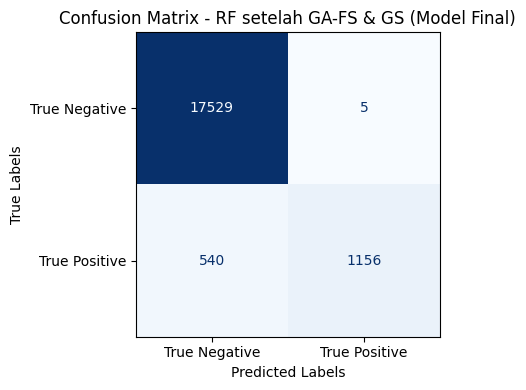

Gambar disimpan: cm_rf_gafs_gs.png


In [ ]:
print('=' * 60)
print('MODEL 3: RF + GA-FS + GS — MODEL FINAL')
print('=' * 60)

best_rf_final = gs.best_estimator_
y_pred_final  = best_rf_final.predict(X_test_sel)

acc_final  = accuracy_score(y_test, y_pred_final)
prec_final = precision_score(y_test, y_pred_final)
rec_final  = recall_score(y_test, y_pred_final)
f1_final   = f1_score(y_test, y_pred_final)

print(f'Fitur terpilih : {selected_features}')
print(f'Best Parameters: {gs.best_params_}')
print(f'Accuracy : {acc_final * 100:.2f}%')
print(f'Precision: {prec_final * 100:.2f}%')
print(f'Recall   : {rec_final * 100:.2f}%')
print(f'F1-Score : {f1_final * 100:.2f}%')

cm_final = confusion_matrix(y_test, y_pred_final)
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(confusion_matrix=cm_final,
    display_labels=['True Negative', 'True Positive']).plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix - RF setelah GA-FS & GS (Model Final)')
ax.set_xlabel('Predicted Labels')
ax.set_ylabel('True Labels')
plt.tight_layout()
plt.savefig('cm_rf_gafs_gs.png', dpi=150)
plt.show()
print('Gambar disimpan: cm_rf_gafs_gs.png')

## 9. Perbandingan Performa Ketiga Model

PERBANDINGAN PERFORMA MODEL
                  Model Accuracy Precision Recall F1-Score
          RF (Baseline)   96.97%    95.06% 69.22%   80.11%
             RF + GA-FS   96.59%    89.22% 69.81%   78.33%
RF + GA-FS + GS (Final)   97.17%    99.57% 68.16%   80.92%


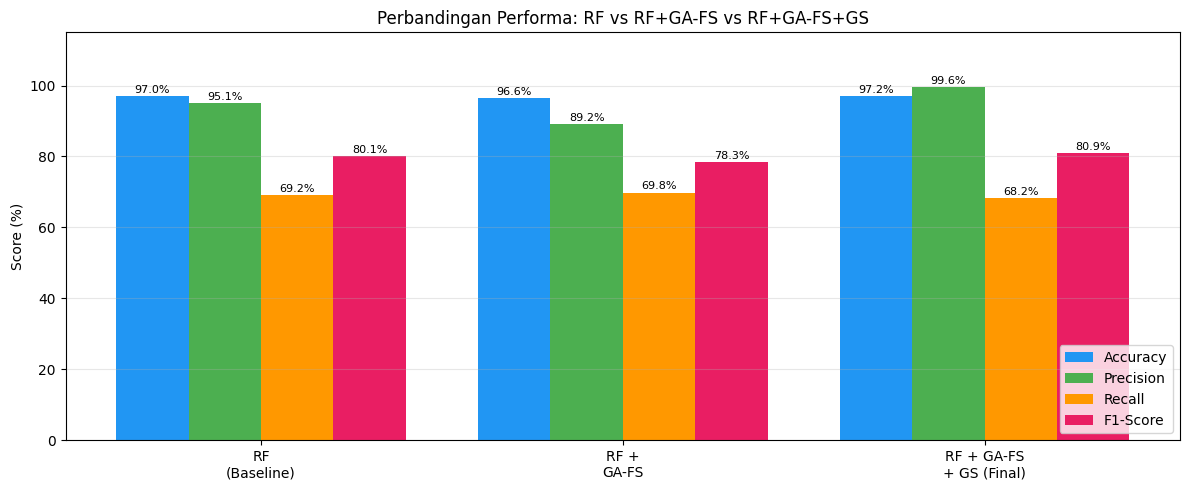

Gambar disimpan: perbandingan_model.png


In [ ]:
print('=' * 60)
print('PERBANDINGAN PERFORMA MODEL')
print('=' * 60)

results = pd.DataFrame({
    'Model'    : ['RF (Baseline)', 'RF + GA-FS', 'RF + GA-FS + GS (Final)'],
    'Accuracy' : [f'{acc_rf*100:.2f}%',   f'{acc_gafs*100:.2f}%',   f'{acc_final*100:.2f}%'],
    'Precision': [f'{prec_rf*100:.2f}%',  f'{prec_gafs*100:.2f}%',  f'{prec_final*100:.2f}%'],
    'Recall'   : [f'{rec_rf*100:.2f}%',   f'{rec_gafs*100:.2f}%',   f'{rec_final*100:.2f}%'],
    'F1-Score' : [f'{f1_rf*100:.2f}%',    f'{f1_gafs*100:.2f}%',    f'{f1_final*100:.2f}%'],
})
print(results.to_string(index=False))

# Visualisasi perbandingan
models     = ['RF\n(Baseline)', 'RF +\nGA-FS', 'RF + GA-FS\n+ GS (Final)']
all_scores = {
    'Accuracy' : [acc_rf,  acc_gafs,  acc_final],
    'Precision': [prec_rf, prec_gafs, prec_final],
    'Recall'   : [rec_rf,  rec_gafs,  rec_final],
    'F1-Score' : [f1_rf,   f1_gafs,   f1_final],
}
x      = np.arange(len(models))
width  = 0.2
colors = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63']
fig, ax = plt.subplots(figsize=(12, 5))
for i, (metric, vals) in enumerate(all_scores.items()):
    bars = ax.bar(x + i*width, [v*100 for v in vals], width,
                  label=metric, color=colors[i])
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{v*100:.1f}%', ha='center', va='bottom', fontsize=8)
ax.set_ylabel('Score (%)')
ax.set_title('Perbandingan Performa: RF vs RF+GA-FS vs RF+GA-FS+GS')
ax.set_xticks(x + width*1.5)
ax.set_xticklabels(models)
ax.legend(loc='lower right')
ax.set_ylim(0, 115)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('perbandingan_model.png', dpi=150)
plt.show()
print('Gambar disimpan: perbandingan_model.png')

In [ ]:
print('=' * 60)
print('RINGKASAN AKHIR')
print('=' * 60)
print(f'Dataset              : diabetes_prediction_dataset.csv')
print(f'Sumber               : kaggle.com/datasets/iammustafatz/diabetes-prediction-dataset')
print(f'Total data           : {len(df_encoded)}')
print(f'Data training        : {len(X_train_all)} (80%)')
print(f'Data testing         : {len(X_test_all)} (20%)')
print(f'Fitur awal ({len(all_features)})       : {all_features}')
print(f'Fitur terpilih ({len(selected_features)})    : {selected_features}')
print(f'Fitur dieliminasi ({len(removed_features)})  : {removed_features}')
print(f'Best Params GS       : {gs.best_params_}')
print()
print(f"{'Model':<30} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1-Score':>10}")
print('-' * 62)
print(f"{'RF (Baseline)':<30} {acc_rf*100:>9.2f}% {prec_rf*100:>9.2f}% {rec_rf*100:>9.2f}% {f1_rf*100:>9.2f}%")
print(f"{'RF + GA-FS':<30} {acc_gafs*100:>9.2f}% {prec_gafs*100:>9.2f}% {rec_gafs*100:>9.2f}% {f1_gafs*100:>9.2f}%")
print(f"{'RF + GA-FS + GS':<30} {acc_final*100:>9.2f}% {prec_final*100:>9.2f}% {rec_final*100:>9.2f}% {f1_final*100:>9.2f}%")
print()
print('Kesimpulan: GA-FS melakukan seleksi fitur relevan, kemudian GridSearchCV')
print('mengoptimalkan parameter RF pada fitur terpilih tersebut.')
print(f'Model final mencapai akurasi {acc_final*100:.2f}%, meningkat dari baseline {acc_rf*100:.2f}%.')

RINGKASAN AKHIR
Dataset              : diabetes_prediction_dataset.csv
Sumber               : kaggle.com/datasets/iammustafatz/diabetes-prediction-dataset
Total data           : 96146
Data training        : 76916 (80%)
Data testing         : 19230 (20%)
Fitur awal (8)       : ['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history', 'bmi', 'HbA1c_level', 'blood_glucose_level']
Fitur terpilih (6)    : ['gender', 'hypertension', 'smoking_history', 'bmi', 'HbA1c_level', 'blood_glucose_level']
Fitur dieliminasi (2)  : ['age', 'heart_disease']
Best Params GS       : {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 100}

Model                            Accuracy  Precision     Recall   F1-Score
--------------------------------------------------------------
RF (Baseline)                      96.97%     95.06%     69.22%     80.11%
RF + GA-FS                         96.59%     89.22%     69.81%     78.33%
RF + GA-FS + GS   